# 🏢 Organisational Knowledge Graph
### Internal Communication Analysis — Enron Email Dataset

This notebook builds a **knowledge graph** from internal email data to reveal:
- Who are the most **influential** and **central** communicators
- What **informal communities** form based on actual communication patterns
- What **topics** each community discusses (via LDA topic modeling)
- How information **flows** and where **bottlenecks** exist

**Data source:** [Enron Email Dataset — Kaggle](https://www.kaggle.com/datasets/wcukierski/enron-email-dataset)

```bash
kaggle datasets download -d wcukierski/enron-email-dataset
unzip enron-email-dataset.zip   # produces emails.csv
pip install pandas networkx pyvis matplotlib scikit-learn gensim
```

In [1]:
#imports
import os, re, email, warnings
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from collections import defaultdict, Counter
from IPython.display import display, HTML

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from pyvis.network import Network

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
print("✅ All imports OK")

✅ All imports OK


In [2]:
#configuration
CSV_PATH        = "emails.csv"   # path to Enron emails.csv
MAX_ROWS        = 20_000         # rows to load (more = richer, slower)
DOMAIN          = "@enron.com"   # keep only internal emails

GRAPH_TOP_N     = 120   # nodes in the interactive graph
STATIC_TOP_N    = 80    # nodes in the static network plot
N_TOPICS        = 8     # LDA topics to discover
MIN_EMAILS_NODE = 5     # drop people with fewer total emails (noise)

OUTPUT_HTML     = "knowledge_graph.html"

In [3]:
#Load and parse
def parse_email_row(raw: str) -> dict:
    msg      = email.message_from_string(raw)
    sender   = (msg.get("From", "") or "").strip().lower()
    to_raw   = (msg.get("To",   "") or "")
    cc_raw   = (msg.get("Cc",   "") or "")
    subject  = (msg.get("Subject", "") or "").strip()

    recipients = [
        r.strip().lower()
        for r in re.split(r"[,\n]", to_raw + "," + cc_raw)
        if r.strip()
    ]

    # Extract plain-text body
    body = ""
    if msg.is_multipart():
        for part in msg.walk():
            if part.get_content_type() == "text/plain":
                body = part.get_payload(decode=True) or ""
                if isinstance(body, bytes):
                    body = body.decode("utf-8", errors="ignore")
                break
    else:
        body = msg.get_payload(decode=True) or msg.get_payload() or ""
        if isinstance(body, bytes):
            body = body.decode("utf-8", errors="ignore")

    return dict(sender=sender, recipients=recipients,
                subject=subject, body=str(body))


print(f"Loading up to {MAX_ROWS:,} rows from '{CSV_PATH}' ...")
raw_df = pd.read_csv(CSV_PATH, nrows=MAX_ROWS)

edges      = []
node_texts = defaultdict(list)   # person → list of text snippets

for _, row in raw_df.iterrows():
    p = parse_email_row(row["message"])
    if not p["sender"] or DOMAIN not in p["sender"]:
        continue

    node_texts[p["sender"]].append((p["subject"] + " " + p["body"])[:500])

    for recipient in p["recipients"]:
        if recipient and DOMAIN in recipient and recipient != p["sender"]:
            edges.append(dict(source=p["sender"], target=recipient,
                              subject=p["subject"]))

print(f"  Parsed {len(raw_df):,} emails")
print(f"  Internal email edges: {len(edges):,}")
print(f"  Unique senders with text: {len(node_texts):,}")

Loading up to 20,000 rows from 'emails.csv' ...
  Parsed 20,000 emails
  Internal email edges: 84,594
  Unique senders with text: 571


In [4]:
#build Graph
weight_counter = defaultdict(int)
for e in edges:
    weight_counter[(e["source"], e["target"])] += 1

G = nx.DiGraph()
for (src, tgt), w in weight_counter.items():
    G.add_edge(src, tgt, weight=w)

# Drop low-activity nodes (noise)
keep = {n for n, d in G.degree(weight="weight") if d >= MIN_EMAILS_NODE}
G    = G.subgraph(keep).copy()

print(f"📊 Graph")
print(f"  Nodes : {G.number_of_nodes():,}")
print(f"  Edges : {G.number_of_edges():,}")
print(f"  Density: {nx.density(G):.6f}")
components = list(nx.weakly_connected_components(G))
print(f"  Weakly connected components: {len(components)}")

📊 Graph
  Nodes : 2,319
  Edges : 12,334
  Density: 0.002295
  Weakly connected components: 5


In [5]:
#network analysis
print("Computing metrics ...")

in_deg  = dict(G.in_degree(weight="weight"))
out_deg = dict(G.out_degree(weight="weight"))
pr      = nx.pagerank(G, weight="weight", alpha=0.85)
bw      = nx.betweenness_centrality(G, weight="weight", normalized=True)

try:
    ev = nx.eigenvector_centrality(G, weight="weight", max_iter=500)
except nx.PowerIterationFailedConvergence:
    ev = {n: 0.0 for n in G.nodes}

# Community detection on undirected view
UG              = G.to_undirected()
communities_raw = nx.community.greedy_modularity_communities(UG, weight="weight")
node_community  = {}
for i, comm in enumerate(communities_raw):
    for node in comm:
        node_community[node] = i

n_communities = len(communities_raw)
print(f"  Communities found: {n_communities}")
print(f"\n  Top 5 by PageRank:")
for name, score in sorted(pr.items(), key=lambda x: -x[1])[:5]:
    print(f"    {name.split('@')[0]:<30} PR={score:.5f}  BW={bw[name]:.5f}")

Computing metrics ...
  Communities found: 14

  Top 5 by PageRank:
    don.baughman                   PR=0.02345  BW=0.01407
    john.arnold                    PR=0.02037  BW=0.04145
    eric.bass                      PR=0.01643  BW=0.02857
    susan.bailey                   PR=0.01175  BW=0.02393
    harry.arora                    PR=0.01063  BW=0.04626


In [9]:
#Topic modeling
# Expanded stopwords — add generic email words + known name noise
EMAIL_STOPWORDS = {
    # original
    "enron","forwarded","original","message","mailto","http","www",
    "subject","from","sent","to","cc","attached","please","thanks",
    "thank","regards","dear","hi","hello","best","yes","let","know",
    "will","would","could","like","also","use","one","may","get",
    "need","make","new","time","ect","com","net","org","pm","am",
    # high-frequency filler showing up in topics
    "this","your","that","with","have","been","they","their","there",
    "about","which","were","from","when","what","into","more","than",
    "mail","email","corp","company","llc","inc",
    # news feed noise
    "news","service","reuters","mentions","english",
    # common email signatures / forward artifacts
    "transaction","site","commissioner",
}

def clean_text(text: str) -> str:
    text   = text.lower()
    text   = re.sub(r"[^a-z\s]", " ", text)
    # Remove single characters and short tokens
    tokens = [t for t in text.split()
              if len(t) > 4 and t not in EMAIL_STOPWORDS]  # raised 3→4 min length
    return " ".join(tokens)

# Build per-node corpus (only nodes in the graph)
graph_nodes  = set(G.nodes)
node_corpus  = {n: clean_text(" ".join(node_texts[n])) for n in graph_nodes
                if node_texts.get(n)}
node_corpus  = {n: t for n, t in node_corpus.items() if t.strip()}

corpus_nodes = list(node_corpus.keys())
corpus_texts = [node_corpus[n] for n in corpus_nodes]

print(f"Corpus: {len(corpus_texts):,} people with email text")

vectorizer = CountVectorizer(max_features=2000, min_df=3, max_df=0.85,
                              ngram_range=(1, 2))
X = vectorizer.fit_transform(corpus_texts)
feature_names = vectorizer.get_feature_names_out()
print(f"Vocabulary: {len(feature_names):,} terms")

print(f"Fitting LDA ({N_TOPICS} topics) ...")
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42,
                                 max_iter=15, learning_method="online", n_jobs=-1)
doc_topic_matrix = lda.fit_transform(X)
print("  ✅ Done\n")

TOP_WORDS    = 8
topic_labels = {}
for t_idx, topic in enumerate(lda.components_):
    top_words         = [feature_names[i] for i in topic.argsort()[-TOP_WORDS:][::-1]]
    topic_labels[t_idx] = ", ".join(top_words)
    print(f"  Topic {t_idx:02d}: {topic_labels[t_idx]}")

Corpus: 497 people with email text
Vocabulary: 2,000 terms
Fitting LDA (8 topics) ...
  ✅ Done

  Topic 00: report, category, energy, credit, power, price, received, attachment
  Topic 01: jason, shanna, america, north, brian, north america, going, hoskins
  Topic 02: phillip, allen, phillip allen, meeting, pallen, george, austin, allen phillip
  Topic 03: monday, november, october, tuesday, meeting, harry, mailbox, trading
  Topic 04: transmission, johnny, resume, numbers, trader, interest, advise, candidate
  Topic 05: robert, caiso, badeer, market, robert badeer, meeting, power, belden
  Topic 06: arnold, jennifer, think, today, enronxgate, monday, fraser, trading
  Topic 07: kayne, susan, power, coulter, kayne coulter, energy, bailey, services


In [10]:
#community topic labeling
# Per-node dominant topic
node_dominant_topic = {}
node_topic_dist     = {}
for i, node in enumerate(corpus_nodes):
    dist = doc_topic_matrix[i]
    node_dominant_topic[node] = int(dist.argmax())
    node_topic_dist[node]     = dist

# Per-community: average topic distribution
community_topic_sum   = defaultdict(lambda: np.zeros(N_TOPICS))
community_member_count = defaultdict(int)
for node in graph_nodes:
    comm = node_community.get(node, -1)
    if node in node_topic_dist:
        community_topic_sum[comm]   += node_topic_dist[node]
        community_member_count[comm] += 1

community_dominant_topic = {}
community_topic_label    = {}
for comm, dist_sum in community_topic_sum.items():
    count   = community_member_count[comm]
    avg     = dist_sum / (count + 1e-9)
    dom     = int(avg.argmax())
    community_dominant_topic[comm] = dom
    community_topic_label[comm]    = topic_labels[dom]

print("Community → Dominant Topic")
print("-" * 70)
for comm in sorted(community_topic_label):
    size = community_member_count[comm]
    dom  = community_dominant_topic[comm]
    print(f"  Comm {comm:2d}  ({size:3d} members)  →  Topic {dom}: {topic_labels[dom][:55]}")

Community → Dominant Topic
----------------------------------------------------------------------
  Comm  0  (138 members)  →  Topic 3: monday, november, october, tuesday, meeting, harry, mai
  Comm  1  ( 57 members)  →  Topic 3: monday, november, october, tuesday, meeting, harry, mai
  Comm  2  (108 members)  →  Topic 7: kayne, susan, power, coulter, kayne coulter, energy, ba
  Comm  3  ( 21 members)  →  Topic 3: monday, november, october, tuesday, meeting, harry, mai
  Comm  4  ( 52 members)  →  Topic 7: kayne, susan, power, coulter, kayne coulter, energy, ba
  Comm  5  ( 46 members)  →  Topic 1: jason, shanna, america, north, brian, north america, go
  Comm  6  ( 32 members)  →  Topic 5: robert, caiso, badeer, market, robert badeer, meeting, 
  Comm  7  ( 24 members)  →  Topic 3: monday, november, october, tuesday, meeting, harry, mai
  Comm  8  (  5 members)  →  Topic 7: kayne, susan, power, coulter, kayne coulter, energy, ba
  Comm  9  (  7 members)  →  Topic 7: kayne, susan, powe

In [11]:
#Summary table
rows = []
for node in G.nodes:
    comm      = node_community.get(node, -1)
    dom_topic = community_dominant_topic.get(comm, -1)
    rows.append({
        "person":           node.split("@")[0],
        "emails_sent":      out_deg.get(node, 0),
        "emails_received":  in_deg.get(node, 0),
        "pagerank":         round(pr.get(node, 0), 5),
        "betweenness":      round(bw.get(node, 0), 5),
        "community":        comm,
        "community_topic":  topic_labels.get(dom_topic, "")[:50],
        "personal_topic":   topic_labels.get(node_dominant_topic.get(node, -1), "")[:50],
    })

summary_df = pd.DataFrame(rows).sort_values("pagerank", ascending=False).reset_index(drop=True)

display(summary_df.head(20).style
    .background_gradient(subset=["pagerank", "betweenness"], cmap="YlOrRd")
    .background_gradient(subset=["emails_sent", "emails_received"], cmap="Blues")
    .format({"pagerank": "{:.5f}", "betweenness": "{:.5f}"})
    .set_caption("Top 20 by PageRank — with community topic labels")
)

,person,emails_sent,emails_received,pagerank,betweenness,community,community_topic,personal_topic
0,don.baughman,136,928,0.02345,0.01407,2,"kayne, susan, power, coulter, kayne coulter, energ","kayne, susan, power, coulter, kayne coulter, energ"
1,john.arnold,2679,499,0.02037,0.04145,0,"monday, november, october, tuesday, meeting, harry","arnold, jennifer, think, today, enronxgate, monday"
2,eric.bass,9218,855,0.01643,0.02857,5,"jason, shanna, america, north, brian, north americ","jason, shanna, america, north, brian, north americ"
3,susan.bailey,265,209,0.01175,0.02393,4,"kayne, susan, power, coulter, kayne coulter, energ","kayne, susan, power, coulter, kayne coulter, energ"
4,harry.arora,73,291,0.01063,0.04626,1,"monday, november, october, tuesday, meeting, harry","monday, november, october, tuesday, meeting, harry"
5,k..allen,192,166,0.00468,0.02066,0,"monday, november, october, tuesday, meeting, harry","monday, november, october, tuesday, meeting, harry"
6,jennifer.medcalf,0,188,0.00416,0.00000,7,"monday, november, october, tuesday, meeting, harry",
7,l..garcia,104,92,0.00328,0.00318,2,"kayne, susan, power, coulter, kayne coulter, energ","kayne, susan, power, coulter, kayne coulter, energ"
8,matthew.lenhart,169,1044,0.00305,0.00180,5,"jason, shanna, america, north, brian, north americ","jason, shanna, america, north, brian, north americ"
9,corry.bentley,52,221,0.00290,0.00171,2,"kayne, susan, power, coulter, kayne coulter, energ","kayne, susan, power, coulter, kayne coulter, energ"


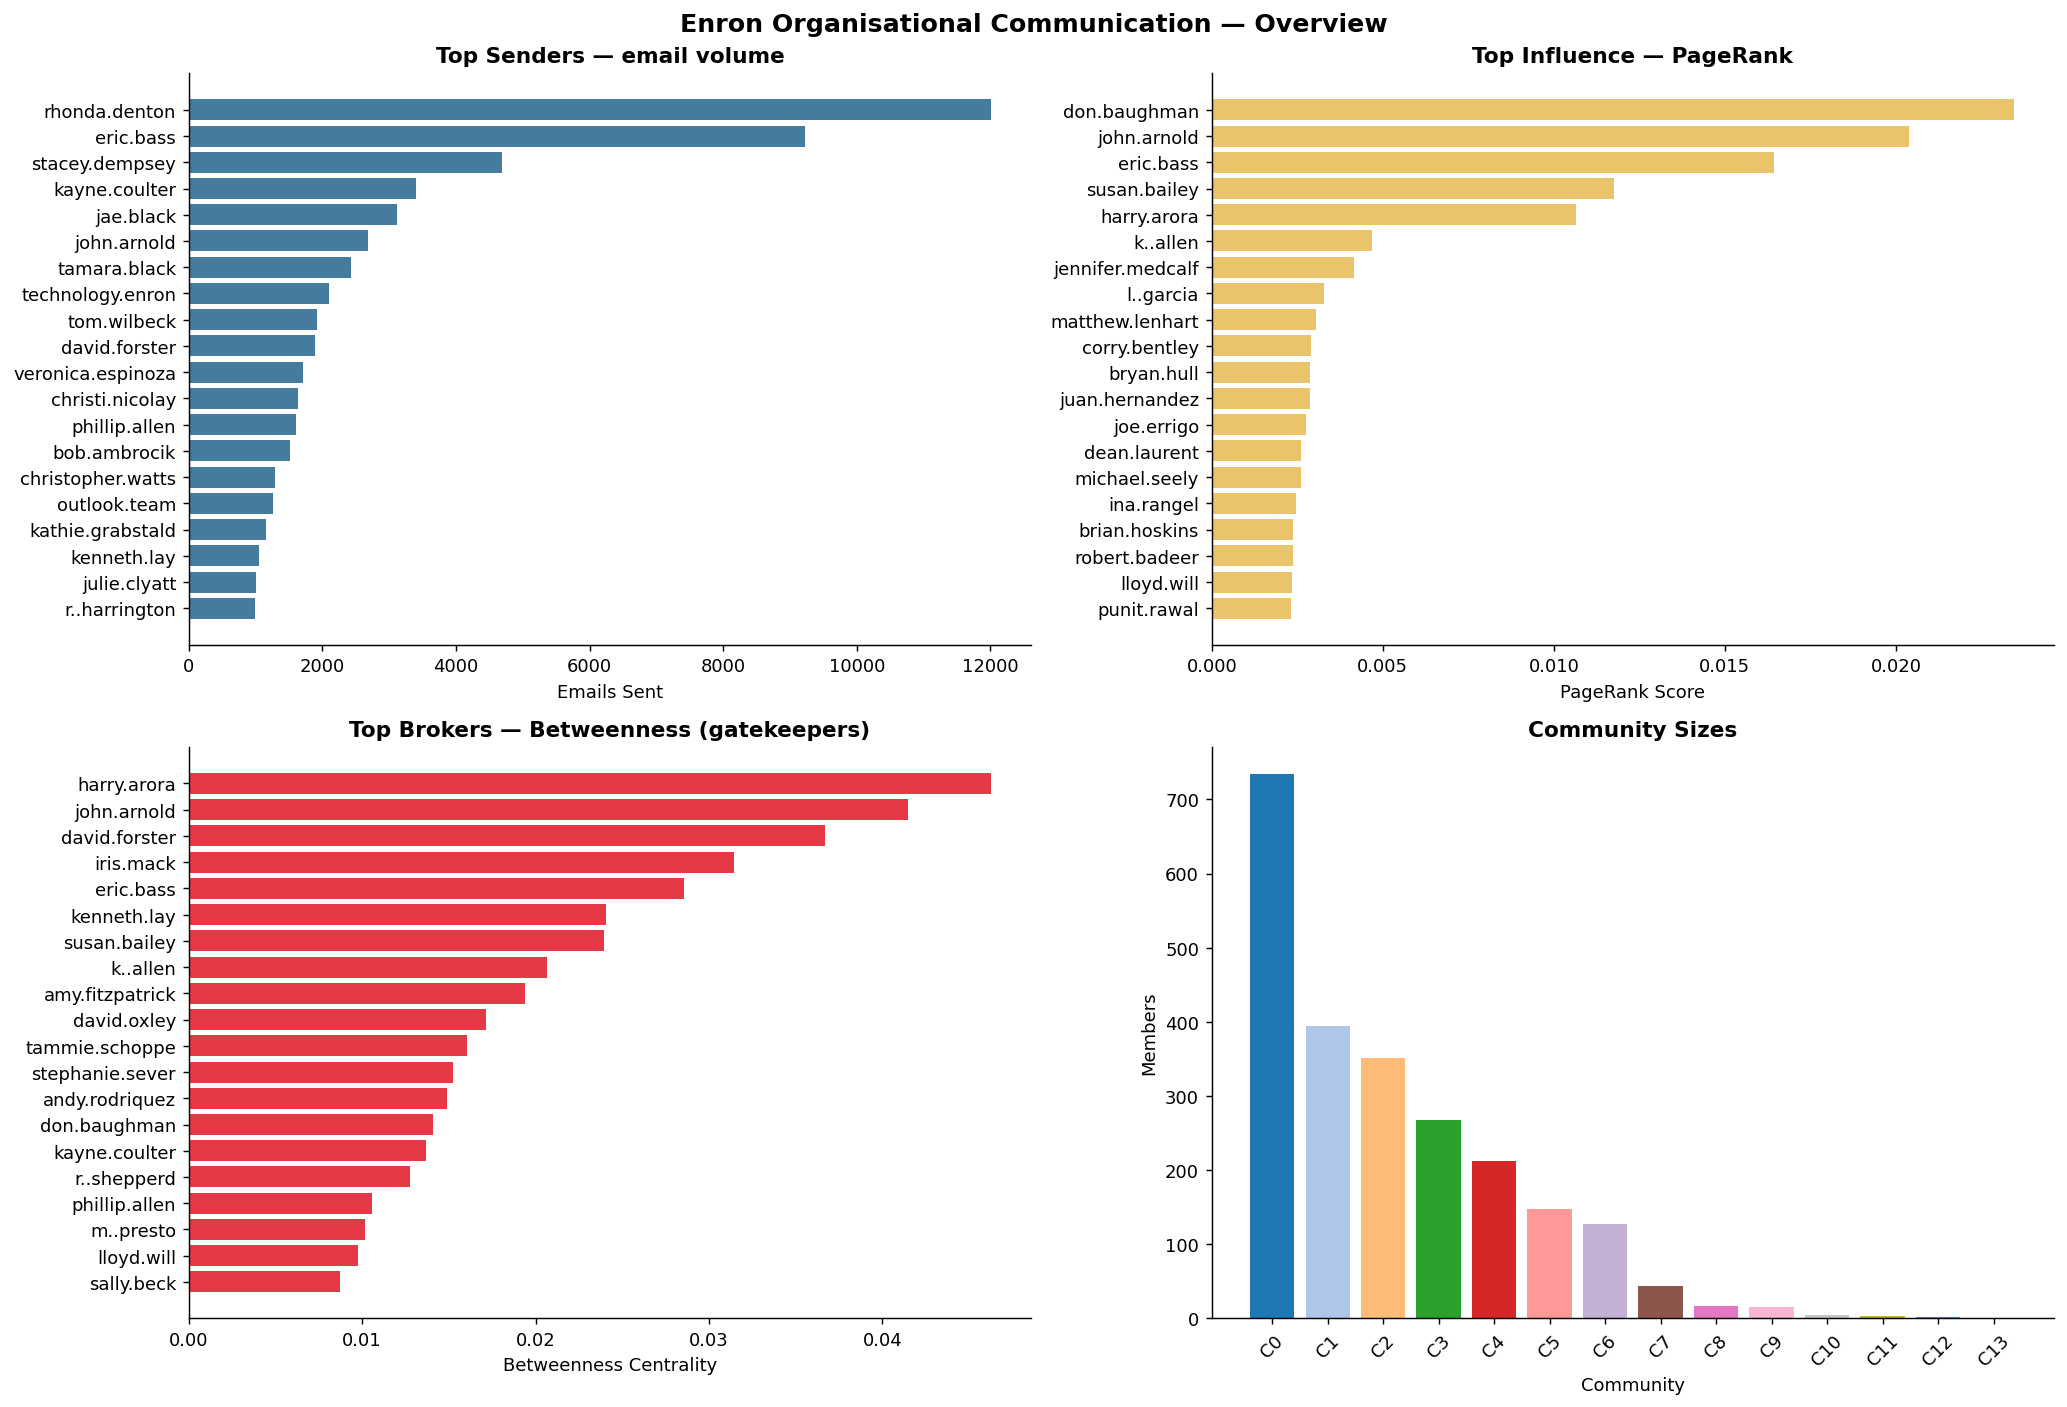

In [12]:
#Overview charts
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Enron Organisational Communication — Overview", fontsize=14, fontweight="bold")

# Top senders
top_senders = sorted(out_deg.items(), key=lambda x: -x[1])[:20]
n_s, v_s = zip(*top_senders)
axes[0,0].barh([n.split("@")[0] for n in n_s][::-1], list(v_s)[::-1], color="#457b9d")
axes[0,0].set_title("Top Senders — email volume", fontweight="bold")
axes[0,0].set_xlabel("Emails Sent")

# Top by PageRank
top_pr = sorted(pr.items(), key=lambda x: -x[1])[:20]
n_p, v_p = zip(*top_pr)
axes[0,1].barh([n.split("@")[0] for n in n_p][::-1], list(v_p)[::-1], color="#e9c46a")
axes[0,1].set_title("Top Influence — PageRank", fontweight="bold")
axes[0,1].set_xlabel("PageRank Score")

# Top by Betweenness
top_bw = sorted(bw.items(), key=lambda x: -x[1])[:20]
n_b, v_b = zip(*top_bw)
axes[1,0].barh([n.split("@")[0] for n in n_b][::-1], list(v_b)[::-1], color="#e63946")
axes[1,0].set_title("Top Brokers — Betweenness (gatekeepers)", fontweight="bold")
axes[1,0].set_xlabel("Betweenness Centrality")

# Community sizes
cmap20      = cm.get_cmap("tab20", n_communities)
comm_sizes  = Counter(node_community.values())
comm_ids    = sorted(comm_sizes.keys())
axes[1,1].bar([f"C{c}" for c in comm_ids],
              [comm_sizes[c] for c in comm_ids],
              color=[cmap20(c % 20) for c in comm_ids])
axes[1,1].set_title("Community Sizes", fontweight="bold")
axes[1,1].set_xlabel("Community")
axes[1,1].set_ylabel("Members")
axes[1,1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("overview_charts.png", dpi=150, bbox_inches="tight")
plt.show()

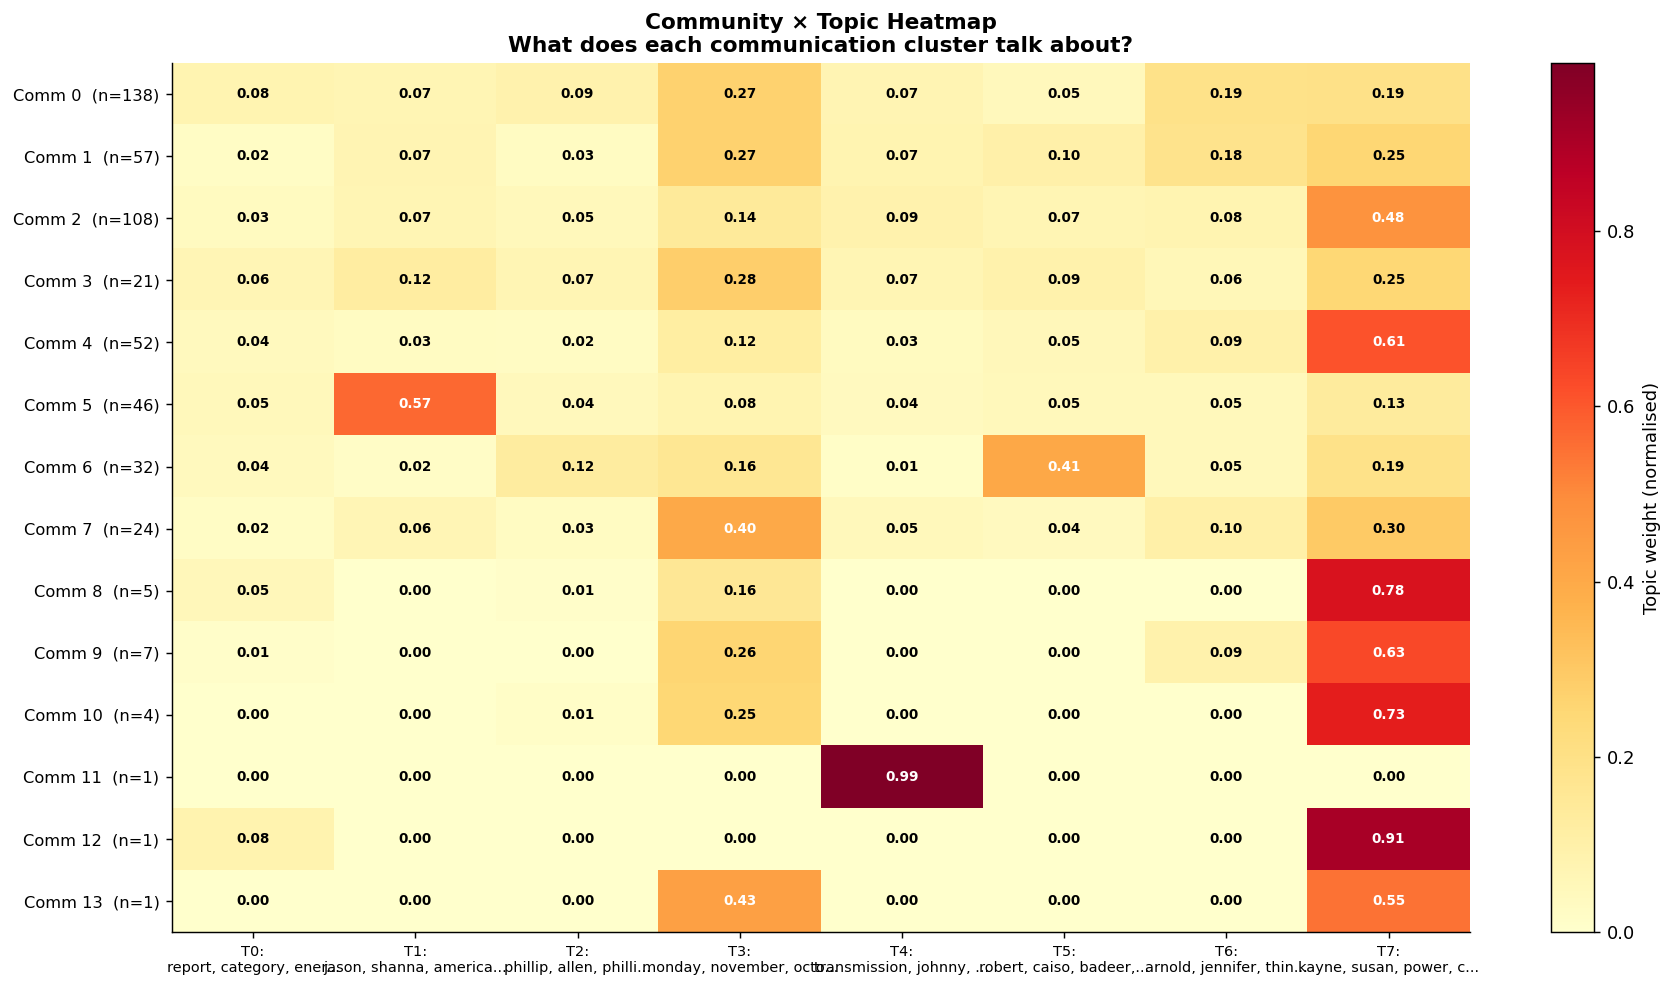

In [13]:
#Topic Heatmap
comm_ids_sorted = sorted(community_topic_sum.keys())
matrix = np.zeros((len(comm_ids_sorted), N_TOPICS))
for i, comm in enumerate(comm_ids_sorted):
    count = community_member_count[comm]
    if count > 0:
        matrix[i] = community_topic_sum[comm] / count

# Normalise rows to sum to 1
matrix_norm = matrix / (matrix.sum(axis=1, keepdims=True) + 1e-9)

short_topic_labels = [f"T{i}:\n{topic_labels[i][:22]}..." for i in range(N_TOPICS)]
row_labels         = [f"Comm {c}  (n={community_member_count[c]})" for c in comm_ids_sorted]

fig, ax = plt.subplots(figsize=(14, max(5, len(comm_ids_sorted) * 0.55)))
im = ax.imshow(matrix_norm, cmap="YlOrRd", aspect="auto", vmin=0)

ax.set_xticks(range(N_TOPICS))
ax.set_xticklabels(short_topic_labels, fontsize=8)
ax.set_yticks(range(len(comm_ids_sorted)))
ax.set_yticklabels(row_labels, fontsize=9)

for i in range(len(comm_ids_sorted)):
    for j in range(N_TOPICS):
        val   = matrix_norm[i, j]
        color = "white" if val > 0.35 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7.5, color=color, fontweight="bold")

plt.colorbar(im, ax=ax, label="Topic weight (normalised)")
ax.set_title("Community × Topic Heatmap\n"
             "What does each communication cluster talk about?",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("topic_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

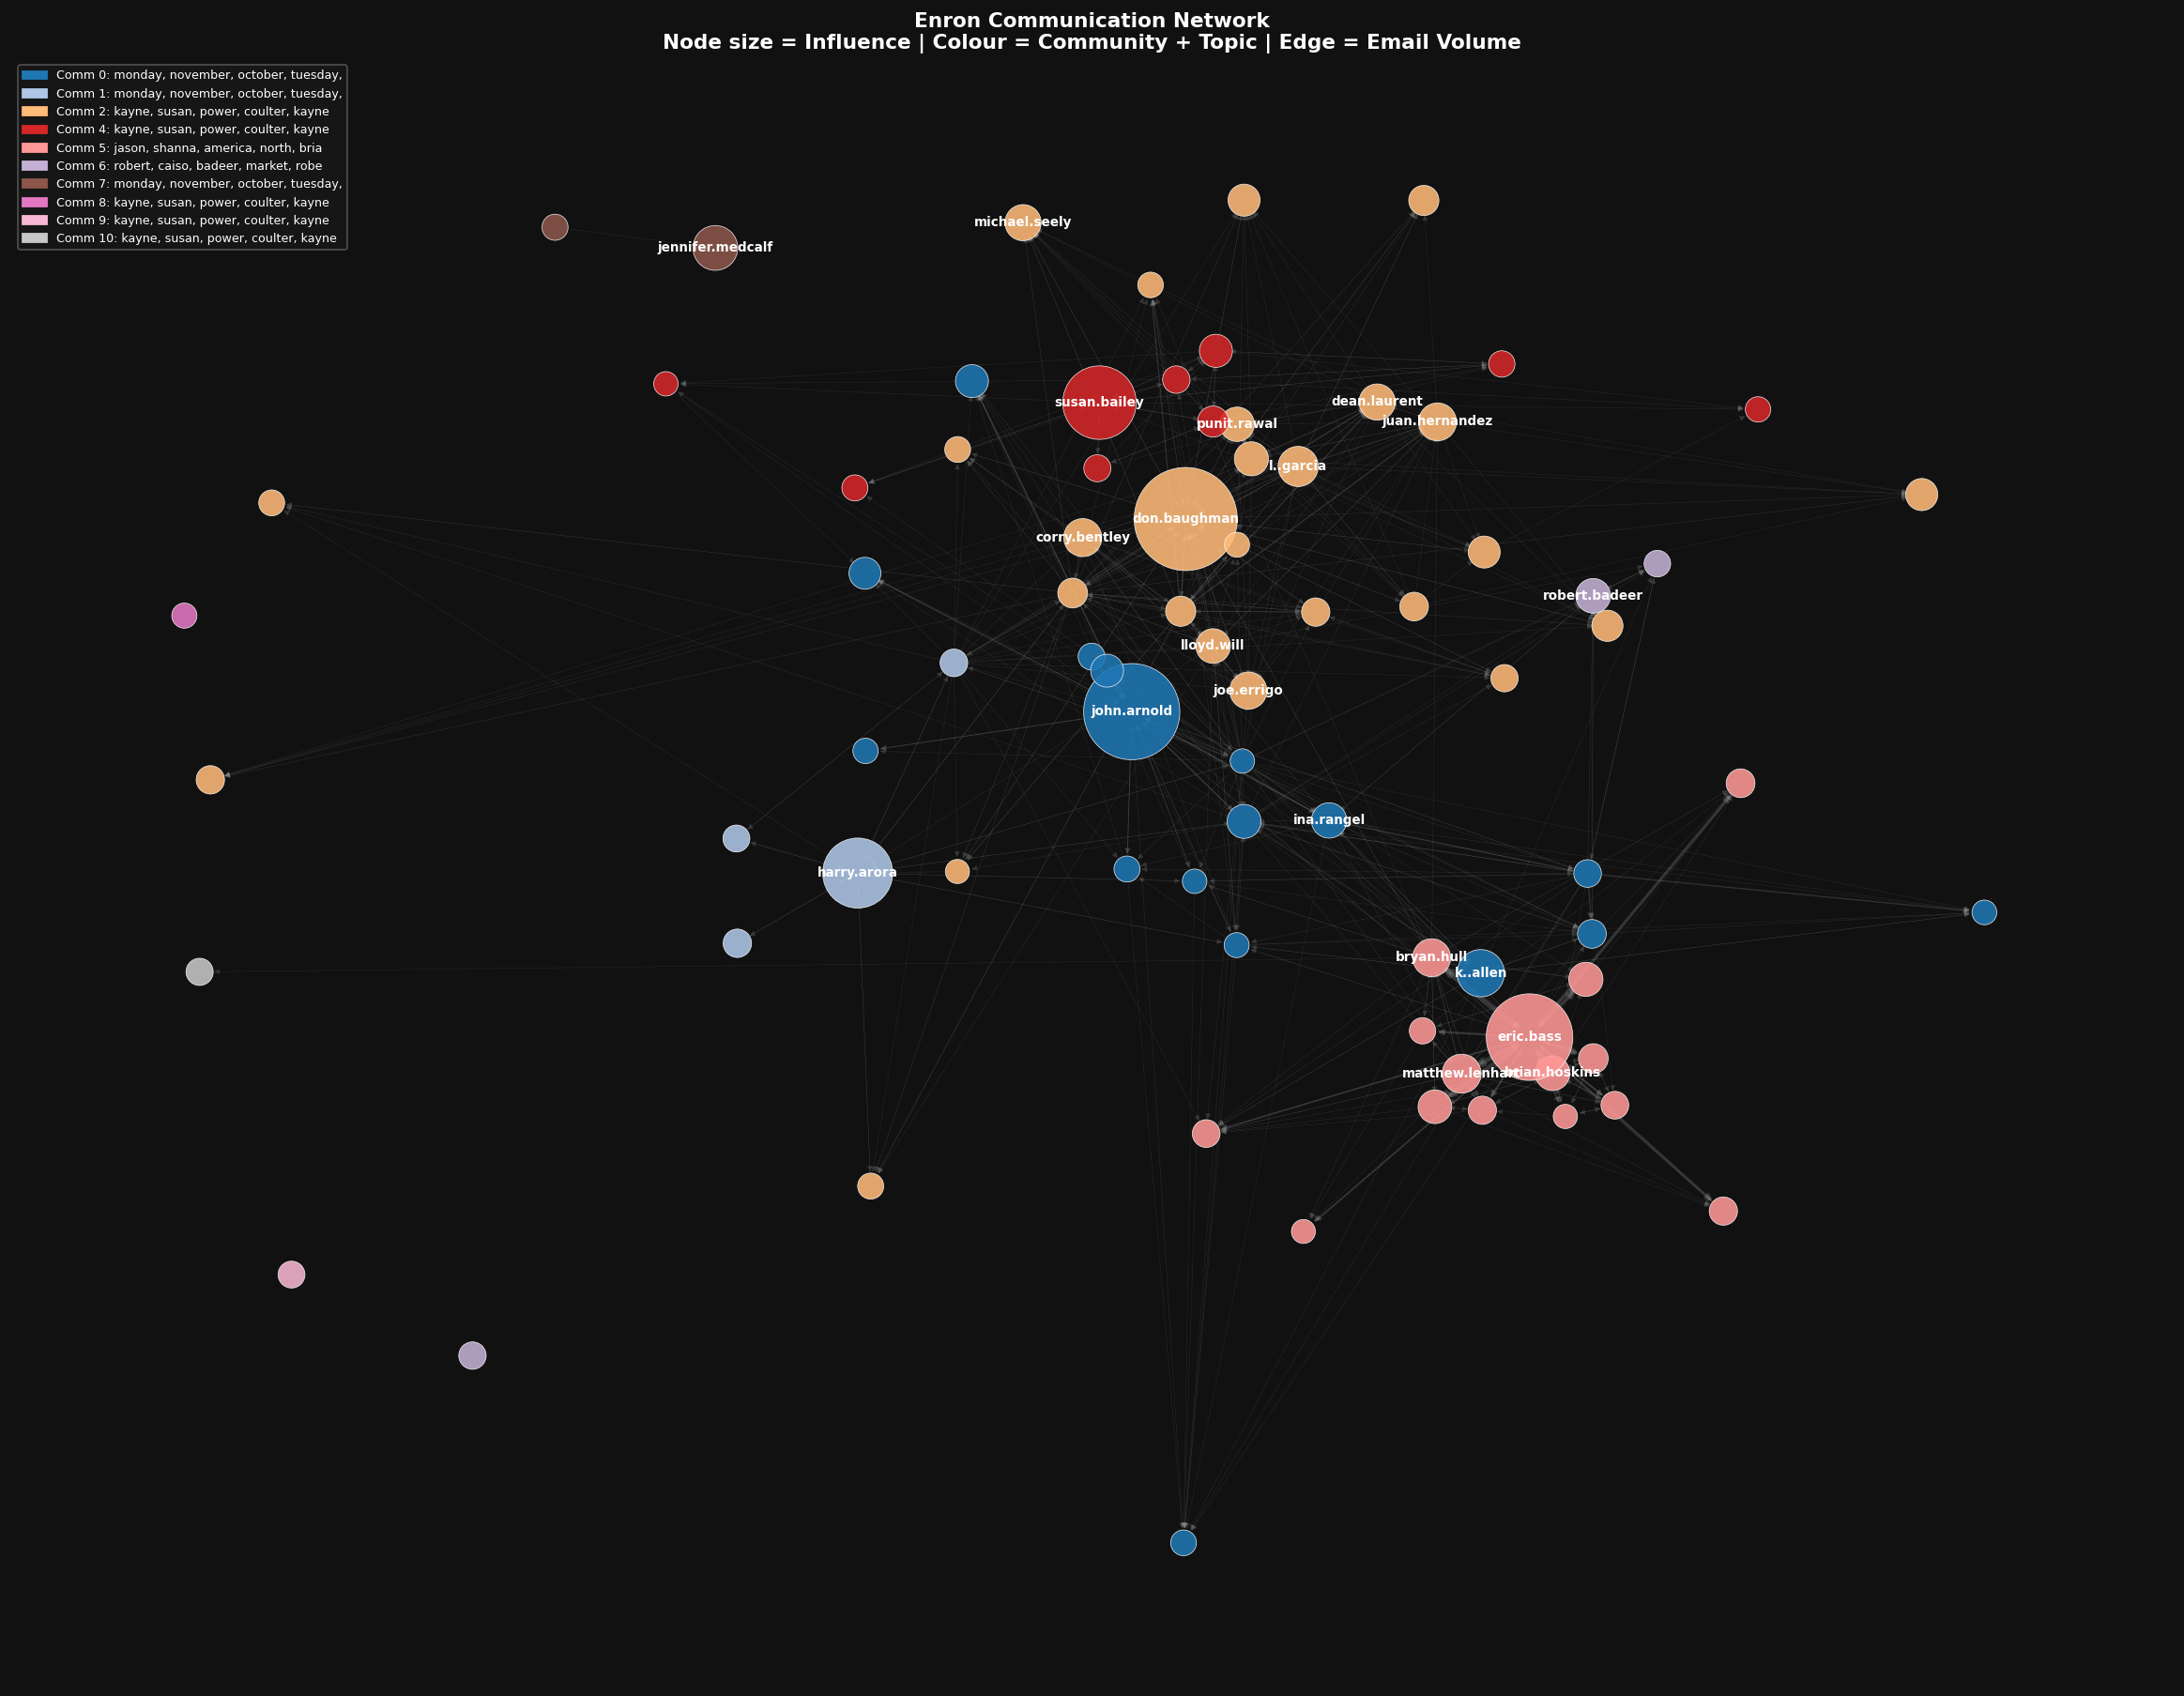

In [14]:
#Static network graph
top_nodes_static = {n for n, _ in sorted(pr.items(), key=lambda x: -x[1])[:STATIC_TOP_N]}
subG = G.subgraph(top_nodes_static).copy()
pos  = nx.spring_layout(subG, seed=42, k=0.65, iterations=60)

pageranks  = np.array([pr.get(n, 0) for n in subG.nodes])
comms      = [node_community.get(n, 0) for n in subG.nodes]
edge_ws    = np.array([subG[u][v]["weight"] for u, v in subG.edges]) if subG.edges else np.array([1])

pr_min, pr_max = pageranks.min(), pageranks.max()
node_sizes     = 200 + 3500 * (pageranks - pr_min) / (pr_max - pr_min + 1e-9)
node_colors    = [cmap20(c % n_communities) for c in comms]
edge_widths    = 0.2 + 3.0 * edge_ws / (edge_ws.max() + 1e-9)

fig, ax = plt.subplots(figsize=(18, 14))
fig.patch.set_facecolor("#111")
ax.set_facecolor("#111")

nx.draw_networkx_nodes(subG, pos, node_size=node_sizes, node_color=node_colors,
                       alpha=0.88, ax=ax, linewidths=0.4, edgecolors="white")
nx.draw_networkx_edges(subG, pos, width=edge_widths, alpha=0.2,
                       arrows=True, arrowsize=7, ax=ax, edge_color="#aaaaaa")

top20  = {n for n, _ in sorted(pr.items(), key=lambda x: -x[1])[:20]}
labels = {n: n.split("@")[0] for n in subG.nodes if n in top20}
nx.draw_networkx_labels(subG, pos, labels, font_size=7.5,
                        font_color="white", font_weight="bold", ax=ax)

# Legend: community → dominant topic
legend_patches = [
    mpatches.Patch(color=cmap20(c % n_communities),
                   label=f"Comm {c}: {topic_labels.get(community_dominant_topic.get(c, 0), '')[:35]}")
    for c in sorted(set(comms))
]
ax.legend(handles=legend_patches, loc="upper left", fontsize=7,
          framealpha=0.3, facecolor="#222", labelcolor="white")

ax.set_title("Enron Communication Network\n"
             "Node size = Influence | Colour = Community + Topic | Edge = Email Volume",
             fontsize=12, color="white", fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("network_static.png", dpi=150, bbox_inches="tight", facecolor="#111")
plt.show()

In [16]:
#Automated insights
print("=" * 65)
print("  KNOWLEDGE GRAPH — KEY INSIGHTS")
print("=" * 65)

top_pr_node  = max(pr, key=pr.get)
top_bw_node  = max(bw, key=bw.get)
top_sender   = max(out_deg, key=out_deg.get)

print(f"\n🏆 Most Influential (PageRank):     {top_pr_node}  [{pr[top_pr_node]:.5f}]")
print(f"🔀 Biggest Broker (Betweenness):    {top_bw_node}  [{bw[top_bw_node]:.5f}]")
print(f"📤 Most Prolific Sender:            {top_sender}  [{out_deg[top_sender]:,} emails]")

print(f"\n📦 Informal Communities: {n_communities}")
for c in sorted(community_member_count):
    dom       = community_dominant_topic.get(c, -1)
    topic_str = topic_labels.get(dom, "")[:55]
    print(f"  Comm {c:2d}  ({community_member_count[c]:3d} members)  →  {topic_str}")

print(f"\n⚠️  Structural Bottlenecks (high betweenness):")
for node, score in sorted(bw.items(), key=lambda x: -x[1])[:5]:
    print(f"  {node.split('@')[0]:<30} bw={score:.5f}")

print(f"\n📁 Saved files:")
print(f"  overview_charts.png  — bar charts")
print(f"  topic_heatmap.png    — community × topic matrix")
print(f"  network_static.png   — static graph")
print(f"  {OUTPUT_HTML}  — interactive browser graph")
print("=" * 65)

  KNOWLEDGE GRAPH — KEY INSIGHTS

🏆 Most Influential (PageRank):     don.baughman@enron.com  [0.02345]
🔀 Biggest Broker (Betweenness):    harry.arora@enron.com  [0.04626]
📤 Most Prolific Sender:            rhonda.denton@enron.com  [12,007 emails]

📦 Informal Communities: 14
  Comm  0  (138 members)  →  monday, november, october, tuesday, meeting, harry, mai
  Comm  1  ( 57 members)  →  monday, november, october, tuesday, meeting, harry, mai
  Comm  2  (108 members)  →  kayne, susan, power, coulter, kayne coulter, energy, ba
  Comm  3  ( 21 members)  →  monday, november, october, tuesday, meeting, harry, mai
  Comm  4  ( 52 members)  →  kayne, susan, power, coulter, kayne coulter, energy, ba
  Comm  5  ( 46 members)  →  jason, shanna, america, north, brian, north america, go
  Comm  6  ( 32 members)  →  robert, caiso, badeer, market, robert badeer, meeting, 
  Comm  7  ( 24 members)  →  monday, november, october, tuesday, meeting, harry, mai
  Comm  8  (  5 members)  →  kayne, susan, po